In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("msa_events_dataset.csv")
df.head()

,event_name,attendance,food,event_type,location,weather,engagement
0,Fall Kickoff,309,yes,social,Livingston,sunny,479
1,Scavenger Hunt,78,no,social,College Ave,sunny,173
2,Chai and Chats: Prophetic Characteristics,78,no,social,College Ave,sunny,230
3,Snacks and Suhba,130,no,social,College Ave,sunny,252
4,MSA Olympics,309,no,social,College Ave,sunny,160


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_name  21 non-null     object
 1   attendance  21 non-null     int64 
 2   food        21 non-null     object
 3   event_type  21 non-null     object
 4   location    21 non-null     object
 5   weather     21 non-null     object
 6   engagement  21 non-null     int64 
dtypes: int64(2), object(5)
memory usage: 1.3+ KB


,attendance,engagement
count,21.000000,21.000000
mean,104.142857,260.000000
std,76.163171,189.959996
min,34.000000,0.000000
25%,61.000000,121.000000
50%,78.000000,218.000000
75%,97.000000,276.000000
max,309.000000,684.000000


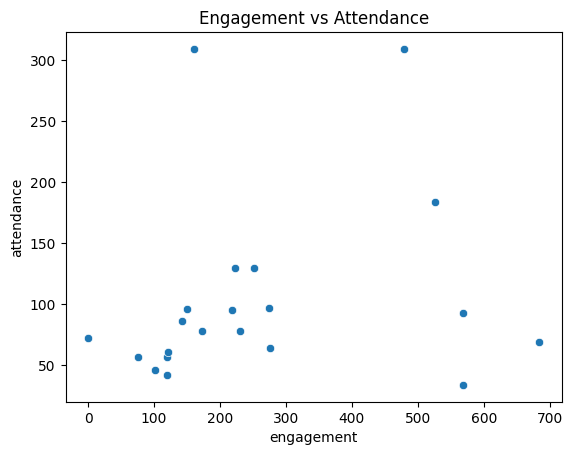

In [4]:
sns.scatterplot(x='engagement', y='attendance', data=df)
plt.title("Engagement vs Attendance")
plt.show()

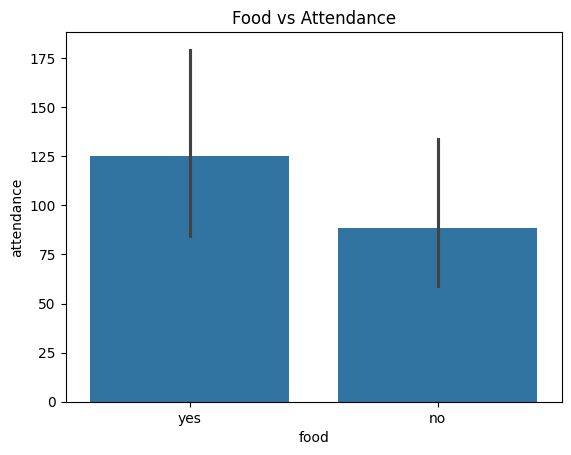

In [5]:
sns.barplot(x='food', y='attendance', data=df)
plt.title("Food vs Attendance")
plt.show()

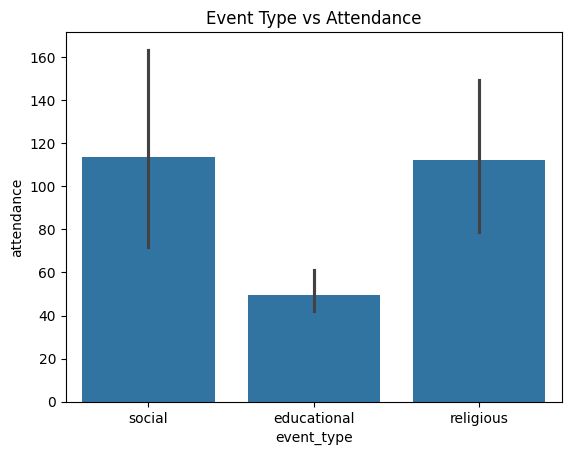

In [6]:
sns.barplot(x='event_type', y='attendance', data=df)
plt.title("Event Type vs Attendance")
plt.show()

In [7]:
df_clean = df.drop('event_name', axis=1)

df_encoded = pd.get_dummies(df_clean)

X = df_encoded.drop('attendance', axis=1)
y = df_encoded['attendance']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    
    print("-----", name, "-----")
    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print()

----- Linear Regression -----
MAE: 97.32872281009982
RMSE: 123.50492760037922

----- Decision Tree -----
MAE: 124.6
RMSE: 156.33745552489972

----- Random Forest -----
MAE: 82.708
RMSE: 119.36168815830312



In [10]:
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
final_preds = model.predict(X_test)

mae = mean_absolute_error(y_test, final_preds)
rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print("Final Model Evaluation")
print("MAE:", mae)
print("RMSE:", rmse)

Final Model Evaluation
MAE: 82.8255
RMSE: 117.23632122234986


In [12]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

engagement                0.432201
weather_sunny             0.181031
location_Busch            0.157884
weather_cold              0.051392
food_yes                  0.040105
food_no                   0.028955
weather_rainy             0.028917
location_College Ave      0.016429
event_type_social         0.015556
event_type_religious      0.013371
event_type_educational    0.013056
weather_cloudy            0.007428
location_Cook/Douglass    0.007240
location_Livingston       0.006436
dtype: float64

In [13]:
def predict_attendance(food, event_type, location, weather, engagement):
    
    input_data = pd.DataFrame([{
        'food': food,
        'event_type': event_type,
        'location': location,
        'weather': weather,
        'engagement': engagement
    }])
    
    input_encoded = pd.get_dummies(input_data)
    input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)
    
    prediction = model.predict(input_encoded)
    
    return int(prediction[0])

In [14]:
predict_attendance("yes", "social", "Livingston", "sunny", 479)

94